In [1]:
%pip install -r requirements.txt
import pandas as pd
import numpy as np
from func import clean_df, tokeniseEmbed_and_oneHot
import re, string, keras, os

# model imports
from keras.layers import Dense, Dropout
from keras.models import Sequential
import keras.layers as layers
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# NLP imports
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.preprocessing import OneHotEncoder

# visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1774697264.712831    9208 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774697264.976328    9208 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774697266.599804    9208 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
data = pd.read_csv('./dataset/data.csv', quotechar='"', escapechar='\\') # read the dataset
print(len(data))
print(data['subject'].unique())
data.sample(10)

39942
<StringArray>
['politicsNews', 'worldnews', 'News', 'politics', 'Government News',
 'left-news']
Length: 6, dtype: str


,label,title,text,subject,date
11591,1,Turkey's Erdogan says expects U.S. to rescind ...,ISTANBUL (Reuters) - Turkish President Tayyip ...,worldnews,"December 21, 2017"
37398,0,UNREAL! REPUBLICAN SENATE CONFIRMS ERIC HOLDER...,LISTEN TO THIS WOMEN SPEAK OF VOTING RIGHTS LI...,Government News,"Apr 23, 2015"
18667,1,Cameroon orders Anglophone region total lockdo...,YAOUNDE (Reuters) - Cameroon authorities on Fr...,worldnews,"September 29, 2017"
27227,0,Trust Fund Frat Bro Explodes At Uber Driver I...,The spoiled son of a New York millionaire went...,News,"March 29, 2016"
18220,1,"After British PM May's speech fiasco, her part...",LONDON (Reuters) - It was meant to be the spee...,worldnews,"October 5, 2017"
36546,0,MUSLIM INVASION OF AMERICA In Full Swing: Obam...,(Welcome) to America We hope you enjoy our...,Government News,"Jun 17, 2016"
34599,0,WHITES NEED NOT APPLY: OBAMA’S NEW MORTGAGE SC...,"Here we go again NO CREDIT, NO PROBLEM Obama h...",politics,"Jan 24, 2016"
29109,0,REMEMBER “Pam” From “The Office”? The Real-Lif...,Jenna Fischer is best known for playing the ve...,politics,"Dec 27, 2017"
25327,0,It Sure Looks Like Donald Trump Would Be Puti...,The Republican Party has been wishing that Ame...,News,"July 25, 2016"
32198,0,SORE LOSER MICHAEL MOORE Calls On “Comrades” T...,Disrupt the Inauguration. The Majority have s...,politics,"Dec 7, 2016"


In [3]:
data = clean_df(df=data, drop_columns=['text','date','reporter','subject']) # clean the dataset
print(len(data))
data.sample(10)

Rows dropped: 703
39239


,label,title,content,year,month,day
38415,0,"WATCH: ANTI-GUN RAPPER, Obama-Fanboy Snoop Dog...",Watch:Here is Snoop Dogg s latest music video ...,2017,3,13
17188,1,"After Somalia's deadliest bombing, a brother's...",When Somalia s deadliest truck bomb exploded o...,2017,10,16
14090,1,"Cuba, North Korea reject 'unilateral and arbit...",Cuba s foreign minister and his North Korean c...,2017,11,23
34941,0,WATCH RESPONSES BY NH FOCUS GROUP TO QUESTIONS...,The answers to questions about Donald Trump by...,2015,8,3
12825,1,Moldova ruling party chief says framed by Russ...,The powerful head of Moldova s ruling party Vl...,2017,12,7
2581,1,No. 2 Senate Republican: health bill to be dis...,"Senator John Cornyn, the No. 2 Senate Republic...",2017,7,24
11768,1,U.S. follows Mexico in backing disputed Hondur...,The United States on Wednesday followed Mexico...,2017,12,20
5934,1,Trump signs order for tighter vetting to preve...,U.S. President Donald Trump on Friday signed a...,2017,1,27
9792,1,House Democrats question if Valeant is withhol...,Democrats on a powerful U.S. congressional pan...,2016,4,26
1955,1,Ex-military officials urge U.S. judge to halt ...,Three high-ranking military officials from the...,2017,8,31


In [5]:
import nltk
# download the stopwords
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/pauldp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/pauldp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/pauldp/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pauldp/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
tkn_cols = ['content','title']
oneHot_cols = []

df_train, df_test = tokeniseEmbed_and_oneHot(data, tkn_cols, oneHot_cols)

df_train.info()
df_test.sample(6)

<class 'pandas.DataFrame'>
Index: 31391 entries, 27519 to 5409
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    31391 non-null  int64 
 1   title    31391 non-null  object
 2   content  31391 non-null  object
 3   year     31391 non-null  Int64 
 4   month    31391 non-null  Int64 
 5   day      31391 non-null  Int64 
dtypes: Int64(3), int64(1), object(2)
memory usage: 1.8+ MB


,label,title,content,year,month,day
28884,0,"[-0.4497242, 0.57549536, 0.26314366, 0.1970715...","[-0.32338035, -0.07932559, 0.4020092, 0.234322...",2016,1,8
15534,1,"[-0.34035078, 0.4440402, 0.21745358, 0.1180342...","[-0.021408955, 0.06125129, 0.57042587, -0.3181...",2017,11,6
20609,0,"[-0.7385487, 0.5122338, 0.3544261, 0.46925047,...","[-0.30641648, 0.27658957, 0.7705933, -0.155422...",2017,8,9
792,1,"[-0.049102604, 0.4505142, 0.22118527, 0.199550...","[-0.33821404, -0.16044249, 0.81127316, -0.8518...",2017,11,6
22553,0,"[-0.73511577, 0.43730688, 0.25389785, 0.287807...","[-0.45265862, 0.6655663, 0.5501999, 0.36984453...",2017,2,12
33685,0,"[-0.5873377, 0.46975908, 0.2508923, 0.11325922...","[-0.22063337, 0.48388565, 1.0319353, -0.106983...",2016,4,14


In [7]:
def prepare_features(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    '''
    Separate features and target, scale numeric columns,
    and stack embedded columns into a single feature matrix.
    Args:
        df (pd.DataFrame): The fully preprocessed dataframe.
    Returns:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Target labels.
    '''
    df = df.copy()
    y = df['label'].values
    df = df.drop(columns=['label'])

    embedding_cols = ['content', 'title']
    scalar_cols = [col for col in df.columns if col not in embedding_cols]

    def parse_embedding(val):
        if isinstance(val, str):
            return np.fromstring(val.strip('[]'), sep=' ')
        return np.array(val)

    embedded = np.hstack([
        np.vstack(df[col].apply(parse_embedding).values)
        for col in embedding_cols if col in df.columns
    ])

    scaler = StandardScaler()
    scaled_scalars = scaler.fit_transform(df[scalar_cols].values.astype(float))

    X = np.hstack([embedded, scaled_scalars])
    return X, y


def build_model(input_dim: int) -> keras.Model:
    '''
    Build a baseline dense neural network for binary classification.
    Args:
        input_dim (int): Number of input features.
    Returns:
        model (keras.Model): Compiled Keras model.
    '''
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


def train_model(df_train: pd.DataFrame, df_test: pd.DataFrame) -> tuple[keras.Model, keras.callbacks.History]:
    '''
    Full pipeline: prepare features, build and train model.
    Split is handled upstream in tokeniseEmbed_and_oneHot.
    Args:
        df_train (pd.DataFrame): Training split.
        df_test (pd.DataFrame): Test split.
    Returns:
        model (keras.Model): Trained Keras model.
        history: Training history.
    '''
    X_train, y_train = prepare_features(df_train)
    X_test,  y_test  = prepare_features(df_test)

    model = build_model(input_dim=X_train.shape[1])
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=50,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )

    loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
    print(f'\nTest Accuracy: {accuracy:.4f}  |  AUC: {auc:.4f}  |  Loss: {loss:.4f}')

    return model, history

In [12]:
if os.path.exists('./local-data/fake_news_classifier.h5') and os.path.exists('./local-data/training_history.npy'):
    load_chk = input('Trained model and history found. Do you want to retrain the model? (y/n): ')
    if load_chk.lower() == 'y':
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            for gpu in gpus:
                print(f'Enabling memory growth for GPU: {gpu}')
                tf.config.experimental.set_memory_growth(gpu, True)
        model, history = train_model(df_train, df_test)
    else:
        model = keras.models.load_model('./local-data/fake_news_classifier.h5')
        history_dict = np.load('./local-data/training_history.npy', allow_pickle=True).item()
        history = keras.callbacks.History()
        history.history = history_dict
else:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            print(f'Enabling memory growth for GPU: {gpu}')
            tf.config.experimental.set_memory_growth(gpu, True)
    model, history = train_model(df_train, df_test)

file_chk = input('Do you want to save the trained model and history? (y/n): ')
if model is not None and history is not None and file_chk.lower() == 'y':
    model.save('./local-data/fake_news_classifier.h5')
    np.save('./local-data/training_history.npy', history.history)

# show model details
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,979 (371.02 KB)

 Trainable params: 94,209 (368.00 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 2 (12.00 B)

None



Final Training Accuracy: 0.9972
Final Validation Accuracy: 0.9978
Final Training Loss: 0.0088
Final Validation Loss: 0.0102


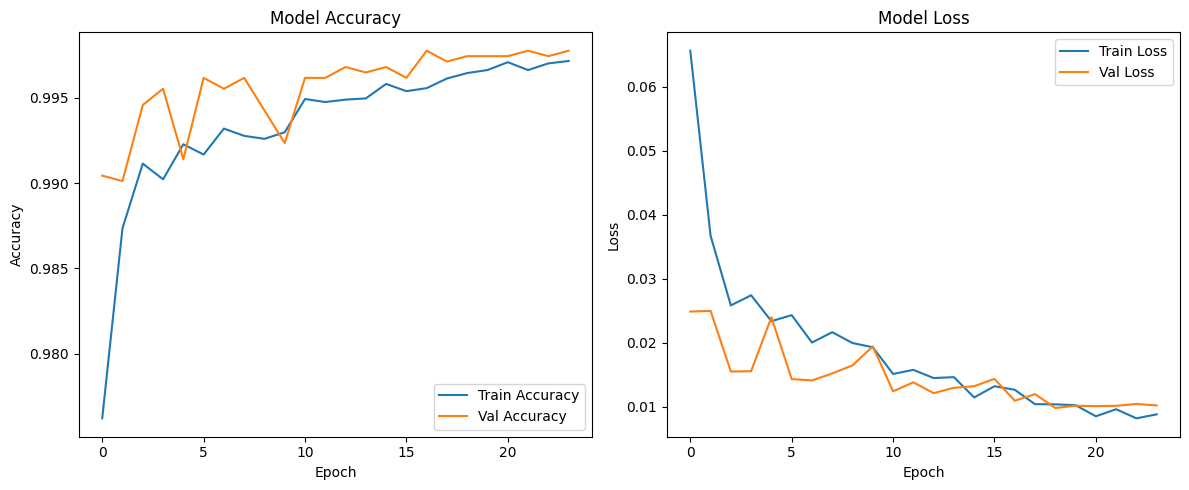

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step


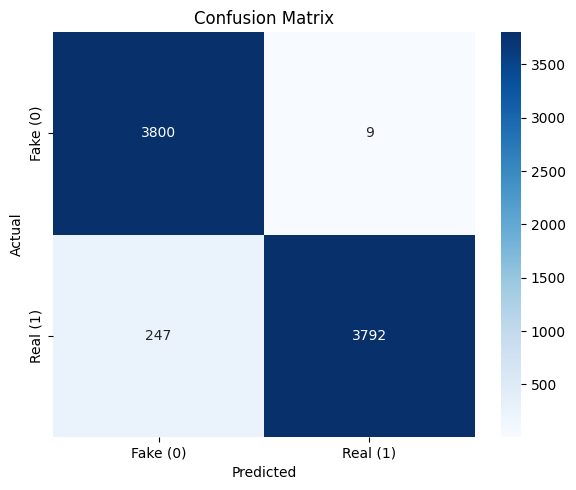

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step


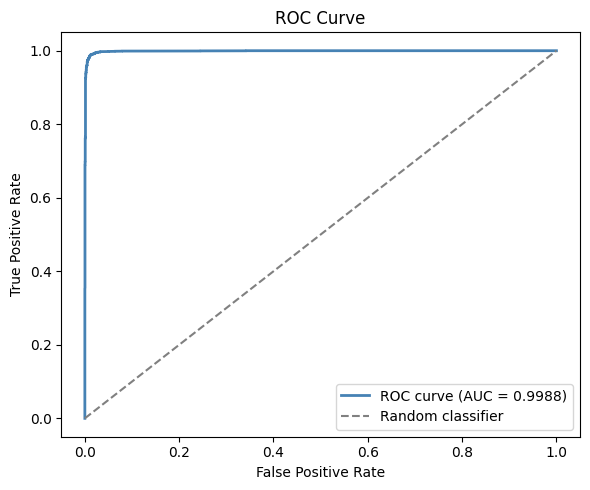

In [9]:
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc
import seaborn as sns

def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def plot_roc_curve(model, X_test, y_test):
    y_prob = model.predict(X_test).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = sk_auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

def show_training_details(history):
    print("\nFinal Training Accuracy: {:.4f}".format(history.history['accuracy'][-1]))
    print("Final Validation Accuracy: {:.4f}".format(history.history['val_accuracy'][-1]))
    print("Final Training Loss: {:.4f}".format(history.history['loss'][-1]))
    print("Final Validation Loss: {:.4f}".format(history.history['val_loss'][-1]))

X_test, y_test = prepare_features(df_test)  # use the already-split test set directly

show_training_details(history)
plot_training_history(history)
plot_confusion_matrix(model, X_test, y_test)
plot_roc_curve(model, X_test, y_test)

In [10]:
#Validation
val_data = pd.read_csv('./dataset/validation_data.csv', quotechar='"', escapechar='\\')
val_data = clean_df(df=val_data, drop_columns=['text', 'date', 'reporter'])


def tokenise_columns_standalone(df, columns):
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    import re, string
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    def remove_punctuation(tokens):
        pattern = re.compile('[%s]' % re.escape(string.punctuation))
        return [pattern.sub('', t) for t in tokens if pattern.sub('', t)]
    for column in columns:
        temp_col = []
        for text in df[column].values:
            tokens = remove_punctuation(word_tokenize(text))
            tokens = [t.lower() for t in tokens if t.lower() not in stop_words]
            tokens = [lemmatizer.lemmatize(t) for t in tokens]
            temp_col.append(tokens)
        df[column] = pd.Series(temp_col)
    return df

def embed_columns_standalone(df, columns):
    for column in columns:
        w2v = Word2Vec(sentences=df[column].values, vector_size=100, window=5, min_count=1, workers=4)
        df[column] = df[column].apply(
            lambda tokens: np.mean([w2v.wv[t] for t in tokens if t in w2v.wv], axis=0)
            if tokens else np.zeros(100)
        )
    return df

# tokenise and embed using a fresh Word2Vec trained on val data only
# (no training data available to reuse, so we embed independently)
val_tkn_cols = ['content', 'title']
val_data = tokenise_columns_standalone(val_data, val_tkn_cols)
val_data = embed_columns_standalone(val_data, val_tkn_cols)

val_data.drop(columns=['subject'], inplace=True)  # drop subject as it was not used in training

X_val, _ = prepare_features(val_data)  # label col exists but is ignored

val_preds = (model.predict(X_val) > 0.5).astype(int).flatten()
val_data['label'] = val_preds

val_data.to_csv('./local-data/validation_data_predicted.csv', index=False)
print(f"Done. {len(val_data)} rows predicted.")
print(val_data['label'].value_counts())

Rows dropped: 23
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step
Done. 4933 rows predicted.
label
1    3137
0    1796
Name: count, dtype: int64


In [11]:
print(val_data.info())
val_data.sample(10)

<class 'pandas.DataFrame'>
RangeIndex: 4933 entries, 0 to 4932
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    4933 non-null   int64 
 1   title    4933 non-null   object
 2   content  4933 non-null   object
 3   year     4933 non-null   Int64 
 4   month    4933 non-null   Int64 
 5   day      4933 non-null   Int64 
dtypes: Int64(3), int64(1), object(2)
memory usage: 245.8+ KB
None


,label,title,content,year,month,day
3700,0,"[-0.053325538, 0.15970153, 0.07631878, 0.07370...","[-0.28199977, 0.15937604, 0.2326281, -0.016339...",2017,1,25
3210,0,"[-0.054443438, 0.17215286, 0.08263242, 0.08130...","[-0.17479308, 0.21800245, 0.3812382, -0.006050...",2015,5,13
31,1,"[-0.04330144, 0.13836066, 0.06355273, 0.065102...","[-0.18433188, 0.24890171, 0.21026771, -0.40218...",2017,9,14
1903,1,"[-0.18301085, 0.56862867, 0.26492983, 0.268646...","[-0.2107302, 0.36245146, 0.39138752, -0.135408...",2016,6,13
4909,0,"[-0.1795332, 0.55912304, 0.2612292, 0.2609608,...","[-0.0036341527, 0.087058224, 0.23871192, 0.298...",2016,2,3
2510,0,"[-0.104542546, 0.33186102, 0.15405795, 0.15712...","[-0.2739098, 0.24951166, 0.23629989, -0.323385...",2016,2,3
511,1,"[-0.044311944, 0.18694843, 0.0891525, 0.078576...","[0.029653322, -0.09293266, 0.06715601, -0.0376...",2017,9,10
3359,0,"[-0.02087779, 0.065024815, 0.028683413, 0.0292...","[-0.07665788, 0.12950778, 0.40816376, -0.11327...",2015,4,6
4233,1,"[-0.1094511, 0.3336676, 0.15468791, 0.1585493,...","[-0.18299761, 0.17451993, 0.22428244, -0.17774...",2017,9,23
2505,0,"[-0.11338344, 0.36106196, 0.16776372, 0.170182...","[-0.17546739, 0.3363781, 0.30870274, -0.229917...",2016,2,5
